In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os

In [99]:
def make_labelled_DAG(df_effects, df_edges):
    g = nx.DiGraph(df_edges)
    edges = g.edges()

    pos = {'A': [0, 2], 'B': [1, 2], 'C': [2, 2], 'D': [3, 2], 'E': [4, 2], 'Treatment': [2, 1], 'Outcome': [2, 0]}

    labels = []
    for start_node, end_node in edges:
        edge_effect = df_effects.loc[start_node, end_node]
        label = f'{edge_effect:.2f}'  
        labels.append(label)
    labels = dict(zip(edges, labels)) 

    node_size = 1200

    fig, ax = plt.subplots(figsize=(8, 6))

    nx.draw_networkx_nodes(g, pos, node_size=node_size, ax=ax)
    nx.draw_networkx_labels(g, pos, font_size=20, ax=ax) 

    nx.draw_networkx_edges(
        g, pos,
        node_size=node_size,
        ax=ax
    )

    nx.draw_networkx_edge_labels(
        g,
        pos,
        labels,
        label_pos=0.3, 
        ax=ax,
    )

In [ ]:
savename="new_continous_test_data_3"

In [101]:
directory = "Causal effects"
file_name= f"ce_reference_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_effects= pd.read_csv(file_path, index_col=0)

In [102]:
df_effects

,A,B,C,D,E,Treatment,Outcome
A,0.0,0.0,0.0,0.0,0.0,1.6,1.6
B,0.0,0.0,0.0,0.0,0.0,0.0,1.5
C,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,2.4,0.0
E,0.0,0.0,0.0,0.0,0.0,1.4,1.7
Treatment,0.0,0.0,0.0,0.0,0.0,0.0,3.0
Outcome,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [104]:
directory = "Edges"
file_name= f"edges_reference_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_edges= pd.read_csv(file_path, index_col=0)

In [105]:
df_edges

,A,B,C,D,E,Treatment,Outcome
A,0.0,0.0,0.0,0.0,0.0,1.0,1.0
B,0.0,0.0,0.0,0.0,0.0,0.0,1.0
C,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,1.0,0.0
E,0.0,0.0,0.0,0.0,0.0,1.0,1.0
Treatment,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Outcome,0.0,0.0,0.0,0.0,0.0,0.0,0.0


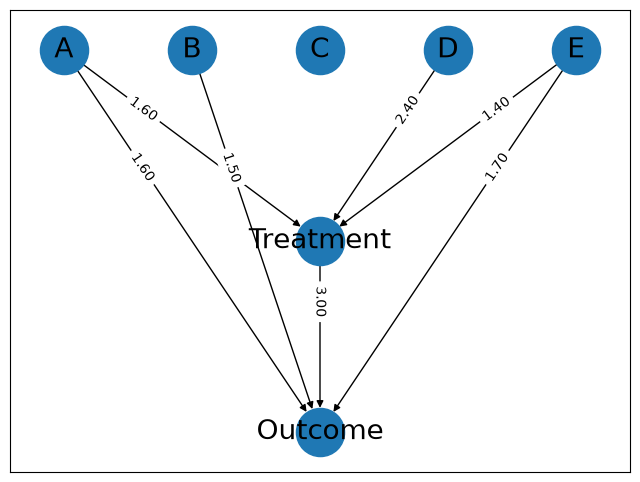

In [106]:
import os
directory ="Labelled DAGs"
file_name=f"reference_{savename}.png"
file_path = os.path.join(directory, file_name)
make_labelled_DAG(df_effects, df_edges)
plt.savefig(file_path)
plt.show()